# Run SGIMC

In [6]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [7]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [8]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_sgimc.gz"}

In [9]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

# if os.path.exists(filename_output):
#     mdttm = time.strftime("%Y%m%d_%H%M%S")
#     os.rename(
#         filename_output,
#         os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
#     )

In [10]:
from sgimc.utils import mc_split

In [11]:
from sgimc.utils import get_submatrix

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sgimc.utils import sparsify_with_mask


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }


def combine_with_identity(X, return_sparse=True):
    """Concatenates X with the identity matrix on the right."""

    assert X.ndim == 2, "Input matrix should have ndim = 2"

    X_add = np.eye(X.shape[0])
    X_comb = np.concatenate((X.toarray(), X_add), axis=1)

    if return_sparse:
        X_comb = sparsify_with_mask(X_comb, X_comb != 0)

    return X_comb

In [13]:
random_state = np.random.RandomState(0x0BADCAFE)

In [14]:
from sgimc.utils import load, save

X, Y, R_full = load(filename_input)
# X = combine_with_identity(X)

In [15]:
print(X.shape, Y.shape, R_full.shape)

(658, 4020) (409, 1860) (658, 409)


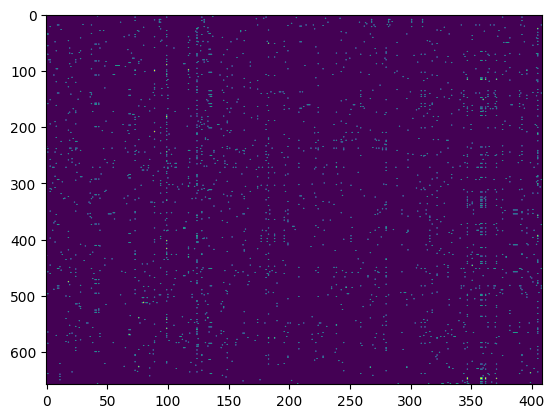

In [16]:
plt.imshow(R_full, aspect="auto")

In [17]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

R_test = get_submatrix(R_full, ind_test)

In [20]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": np.arange(0.1, 0.9, 0.1),
        # "train_size": [0.89],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "C_lasso": [10.0, 5.0, 3.0],
        "C_group": [10.0, 5.0, 3.0],
        "C_ridge": [1.0],
        "rank": [100],
    }
)

In [21]:
from sgimc import SparseGroupIMCClassifier

In [ ]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        # set up the model
        C_lasso, C_group, C_ridge = (
            par_mdl["C_lasso"],
            par_mdl["C_group"],
            par_mdl["C_ridge"],
        )
        imc = SparseGroupIMCClassifier(
            par_mdl["rank"],
            n_threads=-1,
            random_state=42,
            C_lasso=C_lasso,
            C_group=C_group,
            C_ridge=C_ridge,
        )

        # fit on the whole development dataset
        R_train = get_submatrix(R_full, ind_train_all)
        imc.fit(X, Y, R_train)

        # get the score
        prob_full = imc.predict_proba(X, Y)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(R_test, prob_test)
        d1_test = sum(abs(imc.coef_W_).max(axis=1) > 0)
        d2_test = sum(abs(imc.coef_H_).max(axis=1) > 0)

        # run the k-fold CV
        # splt = ShuffleSplit(**par_dtst, random_state=random_state)
        splt = KFold(par_dtst["n_splits"], shuffle=True, random_state=random_state)
        for cv, (ind_train, ind_valid) in enumerate(splt.split(ind_train_all)):

            # prepare the train and test indices
            ind_train, ind_valid = ind_train_all[ind_train], ind_train_all[ind_valid]
            R_train = get_submatrix(R_full, ind_train)
            R_valid = get_submatrix(R_full, ind_valid)

            # fit the model
            imc = SparseGroupIMCClassifier(
                par_mdl["rank"],
                n_threads=-1,
                random_state=42,
                C_lasso=C_lasso,
                C_group=C_group,
                C_ridge=C_ridge,
            )
            imc.fit(X, Y, R_train)

            # compute the class probabilities
            prob_full = imc.predict_proba(X, Y)  # uses own copies of W, H
            prob_valid = get_submatrix(prob_full, ind_valid)
            scores_valid = mc_get_scores(R_valid, prob_valid)
            d1_valid = sum(abs(imc.coef_W_).max(axis=1) > 0)
            d2_valid = sum(abs(imc.coef_H_).max(axis=1) > 0)

            # record the results
            results.append(
                {
                    "train_size": par_dtst["train_size"],
                    "C_group": par_mdl["C_group"],
                    "cv": cv,
                    "rank": par_mdl["rank"],
                    "val_score": scores_valid["auc"],
                    "val_d1": d1_valid,
                    "val_d2": d2_valid,
                    "test_score": scores_test["auc"],
                    "test_d1": d1_test,
                    "test_d2": d2_test,
                }
            )
        # end for
    # end for
# end for

# Save the results in a pickle

with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

---

Test on the one simple case without side information

In [ ]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

R_test = get_submatrix(R_full, ind_test)

In [41]:
X = np.eye(R_full.shape[0])
Y = np.eye(R_full.shape[1])

In [63]:
X, Y, _ = load(filename_input)

In [129]:
ind_train_all, _ = train_test_split(
    ind_dvlp,
    shuffle=False,
    random_state=random_state,
    test_size=0.1,
)

# set up the model
imc = SparseGroupIMCClassifier(
    rank=50,
    n_threads=-1,
    random_state=42,
    C_lasso=8.0,
    C_group=12.0,
    C_ridge=4.0,
)

# fit on the whole development dataset
R_train = get_submatrix(R_full, ind_train_all)
# R_train[R_train == 0] = -1

imc.fit(X, Y, R_train)

# get the score
prob_full = imc.predict_proba(X, Y)
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)
d1_test = sum(abs(imc.coef_W_).max(axis=1) > 0)
d2_test = sum(abs(imc.coef_H_).max(axis=1) > 0)

Identity: {'tn': 26493, 'fn': 166, 'fp': 175, 'tp': 79, 'auc': 0.7465138222680703}
Side info: {'tn': 26400, 'fn': 245, 'fp': 268, 'tp': 0, 'auc': 0.5179792030806623}

{'tn': 26668, 'fn': 245, 'fp': 0, 'tp': 0, 'auc': 0.5} 
rank: 50, C_lasso: 10.0, C_group: 25.0, C_ridge: 0.0
d1: 0/4020, d2: 0/1860


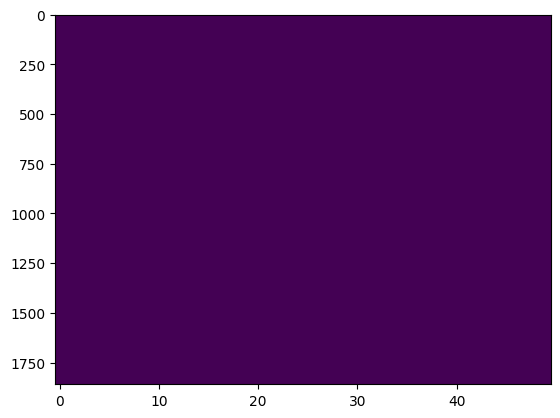

In [ ]:
print(
    scores_test,
    "\n"
    f"rank: {imc.rank}, C_lasso: {imc.C_lasso}, C_group: {imc.C_group}, C_ridge: {imc.C_ridge}\n"
    f"d1: {d1_test}/{X.shape[1]}, d2: {d2_test}/{Y.shape[1]}",
)
plt.imshow(imc.coef_H_, aspect="auto")

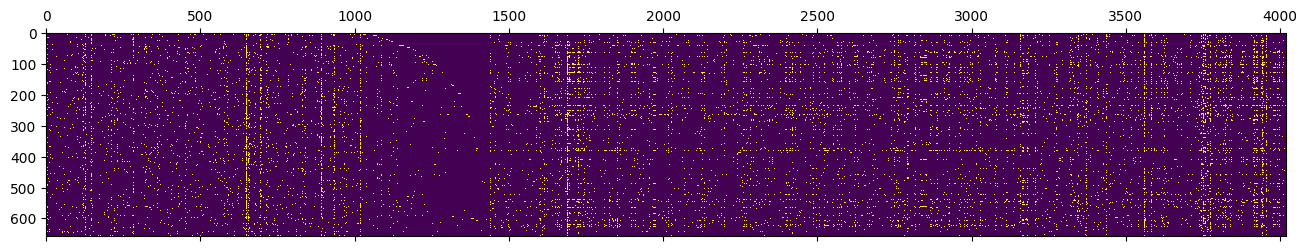

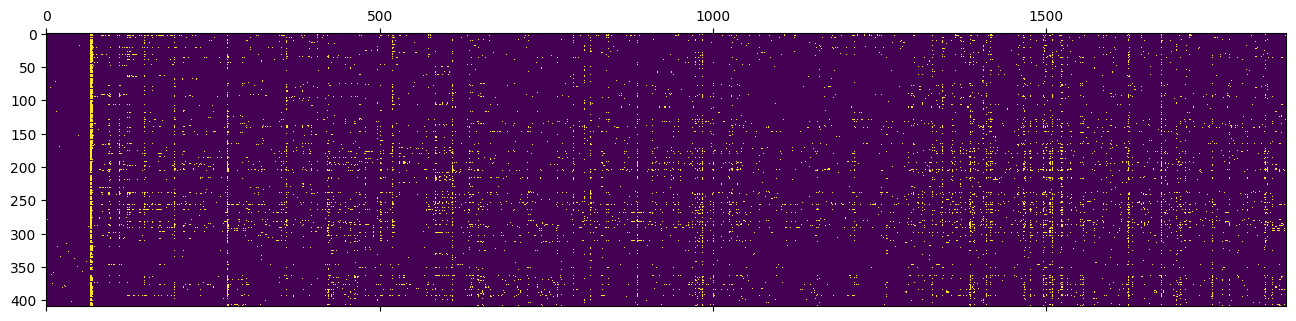

In [ ]:
plt.matshow(X.toarray())
plt.matshow(Y.toarray())